In [1]:
import os
import glob
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
today = datetime.date.today()
date = today.strftime("%B%d")
date

'March05'

Load the tensorboard log files into pandas dataframe

In [3]:
# Gather data
data = []
logs = glob.glob(rf"..\logs\for_paper\uav_random_April29\*\*\*")
for log in logs:
    # print(log)
    print(log.split('\\'))
    experiment_info = log.split('\\')[-2].split('_')
    env_info = log.split('\\')[-3].split('_')
    print(experiment_info)
    algorithm = experiment_info[0]
    st = env_info[-3]

    for e in tf.compat.v1.train.summary_iterator(log):
        for v in e.summary.value:
            if v.tag == 'rollout/ep_rew_mean':
                data.append({
                    'algorithm': algorithm,
                    'set': st,
                    'step': e.step,
                    'reward': v.simple_value
                })
df = pd.DataFrame(data)
os.makedirs("results", exist_ok=True)
df.to_csv(rf"results\uav_random_raw_{date}.csv")
df

['..', 'logs', 'for_paper', 'uav_random_April29', 'new_april16_env10_bhp_a2c', 'A2C_1', 'events.out.tfevents.1744872517.gpu1.1184357.2']
['A2C', '1']

Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`
['..', 'logs', 'for_paper', 'uav_random_April29', 'new_april16_env10_bhp_ars', 'ARS_1', 'events.out.tfevents.1744877908.gpu1.1184357.3']
['ARS', '1']
['..', 'logs', 'for_paper', 'uav_random_April29', 'new_april16_env10_bhp_CrossQ', 'CrossQ_set10_0', 'events.out.tfevents.1745778669.wizard32.292241.0']
['CrossQ', 'set10', '0']
['..', 'logs', 'for_paper', 'uav_random_April29', 'new_april16_env10_bhp_ppo', 'PPO_1', 'events.out.tfevents.1744862900.gpu1.1184357.1']
['PPO', '1']
['..', 'logs', 'for_paper', 'uav_random_April29', 'new_april16_env10_bhp_TQC', 'TQC_1', 'events.out.tfevents.1744912581.gpu1.1184357.5']
['TQC', '1']
['..', 'logs', 'for_paper', 'uav_random_April29', 'new_april16_env10_bhp_trpo', 'TRPO_1', 'events.out.tfevents.1744858441.gpu1.1184357.0'

,algorithm,set,step,reward
0,A2C,env10,2000,-604140.000000
1,A2C,env10,4000,-819565.000000
2,A2C,env10,6000,-762570.000000
3,A2C,env10,8000,-766682.500000
4,A2C,env10,10000,-703106.000000
...,...,...,...,...
98671,TRPO,env9,4988928,-34249.398438
98672,TRPO,env9,4990000,-34249.398438
98673,TRPO,env9,4997120,-33338.601562
98674,TRPO,env9,5000000,-33640.398438


In [4]:
df['algorithm'].unique()

array(['A2C', 'ARS', 'CrossQ', 'PPO', 'TQC', 'TRPO'], dtype=object)

In [5]:
# Scaling the rewards for visualization
df['reward_scaled'] = df['reward'] / 1000000
df['reward_scaled'] = df['reward_scaled'].clip(lower=-2)

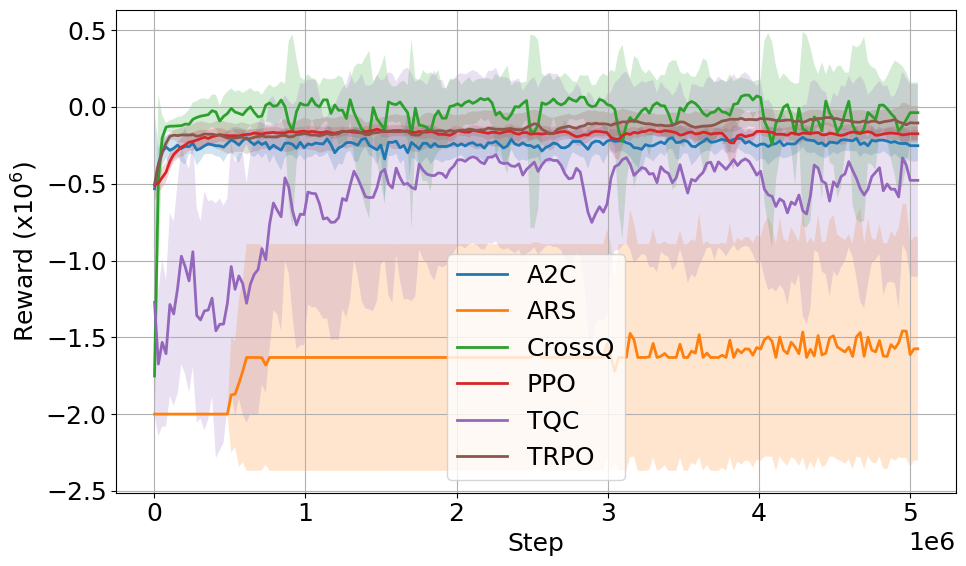

In [6]:
# Define a common x-axis (based on min-max steps across all algorithms)
min_step = df['step'].min()
max_step = df['step'].max()
common_steps = np.linspace(min_step, max_step, 200)

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,6))

# Group by algorithm
for algo, algo_df in df.groupby('algorithm'):
    runs = []

    # For each run (set), interpolate rewards to common steps
    for run_id, run_df in algo_df.groupby('set'):
        x = run_df['step'].values
        y = run_df['reward_scaled'].values
        interp_rewards = np.interp(common_steps, x, y)
        runs.append(interp_rewards)

    runs = np.array(runs)
    mean_rewards = runs.mean(axis=0)
    std_rewards = runs.std(axis=0)

    # Plot with variance shading
    plt.plot(common_steps, mean_rewards, label=algo, linewidth=2)
    plt.fill_between(common_steps, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.2)

plt.xlabel("Step")
plt.ylabel("Reward (x$10^6$)")
# plt.title("RL Algorithms Reward Curves with Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()
os.makedirs("plots", exist_ok=True)
plt.savefig(rf"plots/uav_random_{date}.png")
plt.show()

In [7]:
a2c_df = df[df['algorithm']=='A2C']
ppo_df = df[df['algorithm']=='PPO']
trpo_df = df[df['algorithm']=='TRPO']
ars_df = df[df['algorithm']=='ARS']
crossq_df = df[df['algorithm']=='CrossQ']
tqc_df = df[df['algorithm']=='TQC']


a2c_data = {"Setting": "AB", 
            "Algorithm": "A2C", 
            "Mean": a2c_df['reward'].mean(),
            "SD": a2c_df['reward'].std(),
            "Max": a2c_df['reward'].max(),
            "Range": (a2c_df['reward'].max() - a2c_df['reward'].min())}
ppo_data = {"Setting": "AB", 
            "Algorithm": "PPO", 
            "Mean": ppo_df['reward'].mean(),
            "SD": ppo_df['reward'].std(),
            "Max": ppo_df['reward'].max(),
            "Range": (ppo_df['reward'].max() - ppo_df['reward'].min())}
trpo_data = {"Setting": "AB", 
            "Algorithm": "TRPO", 
            "Mean": trpo_df['reward'].mean(),
            "SD": trpo_df['reward'].std(),
            "Max": trpo_df['reward'].max(),
            "Range": (trpo_df['reward'].max() - trpo_df['reward'].min())}
ars_data = {"Setting": "AB", 
            "Algorithm": "ARS", 
            "Mean": ars_df['reward'].mean(),
            "SD": ars_df['reward'].std(),
            "Max": ars_df['reward'].max(),
            "Range": (ars_df['reward'].max() - ars_df['reward'].min())}
crossq_data = {"Setting": "AB", 
            "Algorithm": "CrossQ", 
            "Mean": crossq_df['reward'].mean(),
            "SD": crossq_df['reward'].std(),
            "Max": crossq_df['reward'].max(),
            "Range": (crossq_df['reward'].max() - crossq_df['reward'].min())}
tqc_data = {"Setting": "AB", 
            "Algorithm": "TQC", 
            "Mean": tqc_df['reward'].mean(),
            "SD": tqc_df['reward'].std(),
            "Max": tqc_df['reward'].max(),
            "Range": (tqc_df['reward'].max() - tqc_df['reward'].min())}


set_tab_df = pd.DataFrame([a2c_data, ppo_data, trpo_data, ars_data, crossq_data, tqc_data])
set_tab_df

,Setting,Algorithm,Mean,SD,Max,Range
0,AB,A2C,-2.435690e+05,9.897454e+04,-82030.796875,2.356812e+06
1,AB,PPO,-1.806769e+05,6.685461e+04,-76667.000000,6.549888e+05
2,AB,TRPO,-1.404167e+05,1.010524e+05,6722.799805,6.613292e+05
3,AB,ARS,-1.534536e+06,4.378147e+06,-140810.000000,1.976100e+07
4,AB,CrossQ,-5.543857e+04,3.986117e+05,159250.000000,1.176146e+07
5,AB,TQC,-8.592178e+05,2.713736e+06,14193.700195,1.851907e+07


In [8]:
set_tab_df_sc = set_tab_df.select_dtypes(include='number') / 1000000
set_tab_df_sc.insert(0, 'Setting', set_tab_df['Setting'])
set_tab_df_sc.insert(1, 'Algorithm', set_tab_df['Algorithm'])
set_tab_df_sc

,Setting,Algorithm,Mean,SD,Max,Range
0,AB,A2C,-0.243569,0.098975,-0.082031,2.356812
1,AB,PPO,-0.180677,0.066855,-0.076667,0.654989
2,AB,TRPO,-0.140417,0.101052,0.006723,0.661329
3,AB,ARS,-1.534536,4.378147,-0.140810,19.761000
4,AB,CrossQ,-0.055439,0.398612,0.159250,11.761465
5,AB,TQC,-0.859218,2.713736,0.014194,18.519074


In [9]:
set_tab_df_sc.to_csv(rf"results/uav_random_results_{date}.csv")